# **Data Science**
## project 1
Table of Contents
1. Setup

2. Task 1: Data collection & Data Understand

3. Task 2: Data Cleaning & Preprocessing

4. Task 3: Exploratory Data Analysis (EDA)
5. Task 4: Data Visualization

## 1. Setup

In [35]:
# Import modules
import numpy as np  # Library for numerical computing and array operations
import pandas as pd  # Library for handling tabular data
import matplotlib.pyplot as plt  # Library for basic data visualization
import seaborn as sns  # Library for statistical data visualization

## 2. Task 1: Data Collection & Dataset Understand

### 2.1. Load data and connect with google drive

In [36]:
# Read Data collection
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/decodelabs/project1"

/content/drive/MyDrive/decodelabs/project1


In [38]:
# Check if the path is correctly set.
from pathlib import Path

PATH = Path.cwd() / "data"

Data_file = PATH / "pjm_hourly_est.csv"

# Check if path exists
if Data_file.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


### 2.2. Data Overview




In [39]:
#load the dataset as pd.DataFrame
data = pd.read_csv(Data_file)

print(f"Data shape: {data.shape}")

Data shape: (178262, 13)


In [40]:
#show the first 5 Rows of the data
print("--- First 5 Rows ---")
data.head()

--- First 5 Rows ---


,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
0,1998-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1,1998-12-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
2,1998-12-31 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
3,1998-12-31 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
4,1998-12-31 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0


In [41]:
#show detailed information about data
print("\n--- Data Info ---")
data.info()


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178262 entries, 0 to 178261
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  178262 non-null  object 
 1   AEP       121273 non-null  float64
 2   COMED     66497 non-null   float64
 3   DAYTON    121275 non-null  float64
 4   DEOK      57739 non-null   float64
 5   DOM       116189 non-null  float64
 6   DUQ       119068 non-null  float64
 7   EKPC      45334 non-null   float64
 8   FE        62874 non-null   float64
 9   NI        58450 non-null   float64
 10  PJME      145366 non-null  float64
 11  PJMW      143206 non-null  float64
 12  PJM_Load  32896 non-null   float64
dtypes: float64(12), object(1)
memory usage: 17.7+ MB


In [42]:
#show summary statistics for the numerical columns.
print("\n--- Summary Statistics ---")
data.describe()


--- Summary Statistics ---


,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
count,121273.000000,66497.000000,121275.000000,57739.000000,116189.000000,119068.000000,45334.000000,62874.000000,58450.000000,145366.000000,143206.000000,32896.000000
mean,15499.513717,11420.152112,2037.851140,3105.096486,10949.203625,1658.820296,1464.218423,7792.159064,11701.682943,32080.222831,5602.375089,29766.427408
std,2591.399065,2304.139517,393.403153,599.859026,2413.946569,301.740640,378.868404,1331.268006,2371.498701,6464.012166,979.142872,5849.769954
min,9581.000000,7237.000000,982.000000,907.000000,1253.000000,1014.000000,514.000000,0.000000,7003.000000,14544.000000,487.000000,17461.000000
25%,13630.000000,9780.000000,1749.000000,2687.000000,9322.000000,1444.000000,1185.000000,6807.000000,9954.000000,27573.000000,4907.000000,25473.000000
50%,15310.000000,11152.000000,2009.000000,3013.000000,10501.000000,1630.000000,1386.000000,7700.000000,11521.000000,31421.000000,5530.000000,29655.000000
75%,17200.000000,12510.000000,2279.000000,3449.000000,12378.000000,1819.000000,1699.000000,8556.000000,12896.750000,35650.000000,6252.000000,33073.250000
max,25695.000000,23753.000000,3746.000000,5445.000000,21651.000000,3054.000000,3490.000000,14032.000000,23631.000000,62009.000000,9594.000000,54030.000000


In [43]:
#show duplicates
print("\nTotal Duplicated Rows: ")
data.duplicated().sum()


Total Duplicated Rows: 


np.int64(0)

In [44]:
#check missing values
print("\n--- Missing Values Per Column ---")
data.isnull().sum()


--- Missing Values Per Column ---


,0
Datetime,0
AEP,56989
COMED,111765
DAYTON,56987
DEOK,120523
DOM,62073
DUQ,59194
EKPC,132928
FE,115388
NI,119812


## 3. Task 2: Data cleaning & preprocessing

### 3.1. Deleting columns with a lot of missing data and unused columns

In [45]:
# deleting columns with a lot of missing data
data = data.drop(columns = ['COMED','DEOK','EKPC','FE','NI','PJM_Load'])

### 3.2. Dealing missing values

In [46]:
# Columns to impute with the forward fill
cols_to_fill = ['AEP', 'DAYTON', 'DOM', 'DUQ', 'PJME', 'PJMW']

data = data.fillna(method='ffill')
data = data.fillna(method='bfill')

/tmp/ipykernel_21284/3115279435.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')
/tmp/ipykernel_21284/3115279435.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill')


In [47]:
if 'Datetime' in data.columns:
    data['Datetime'] = pd.to_datetime(data['Datetime'])
    data['Hour'] = data['Datetime'].dt.hour
    data['DayOfWeek'] = data['Datetime'].dt.dayofweek
    data['Month'] = data['Datetime'].dt.month
    data['Year'] = data['Datetime'].dt.year

    data.set_index('Datetime', inplace=True)

In [48]:
#check missing values
data.isnull().sum()

,0
AEP,0
DAYTON,0
DOM,0
DUQ,0
PJME,0
PJMW,0
Hour,0
DayOfWeek,0
Month,0
Year,0


## 4. Task 3: Exploratory Data Analysis (EDA)

In [49]:
print("--- Summary Statistics After Cleaning ---")
print(data.describe())

print("\n--- Average Energy Consumption by Region ---")
regions = ['AEP', 'DAYTON', 'DOM', 'DUQ', 'PJME', 'PJMW']
print(data[regions].mean())

max_region = data[regions].mean().idxmax()
min_region = data[regions].mean().idxmin()
print(f"\nHighest energy consuming region on average: {max_region}")
print(f"Lowest energy consuming region on average: {min_region}")

print("\n--- Correlation Matrix between Regions ---")
print(data[regions].corr())

print("\n--- Average Consumption by Hour for PJME ---")
print(data.groupby('Hour')['PJME'].mean())

print("\n--- Average Consumption by Month for PJME ---")
print(data.groupby('Month')['PJME'].mean())

--- Summary Statistics After Cleaning ---
                 AEP         DAYTON            DOM            DUQ  \
count  178262.000000  178262.000000  178262.000000  178262.000000   
mean    14841.057197    1900.435589   10375.672045    1592.135548   
std      2344.082056     381.874872    2113.714934     264.118764   
min      9581.000000     982.000000    1253.000000    1014.000000   
25%     13478.000000    1596.000000    9389.000000    1458.000000   
50%     13745.000000    1768.000000    9389.000000    1458.000000   
75%     16185.000000    2138.000000   11248.750000    1716.000000   
max     25695.000000    3746.000000   21651.000000    3054.000000   

                PJME           PJMW           Hour      DayOfWeek  \
count  178262.000000  178262.000000  178262.000000  178262.000000   
mean    31050.094131    5498.585223      11.501705       2.999316   
std      6225.919267     902.333813       6.921759       1.999543   
min     14544.000000     487.000000       0.000000       0.0

## 5. Task 4: Data Visualization

/tmp/ipykernel_21284/4060130312.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_consumption.index, y=mean_consumption.values, palette="Blues_r")


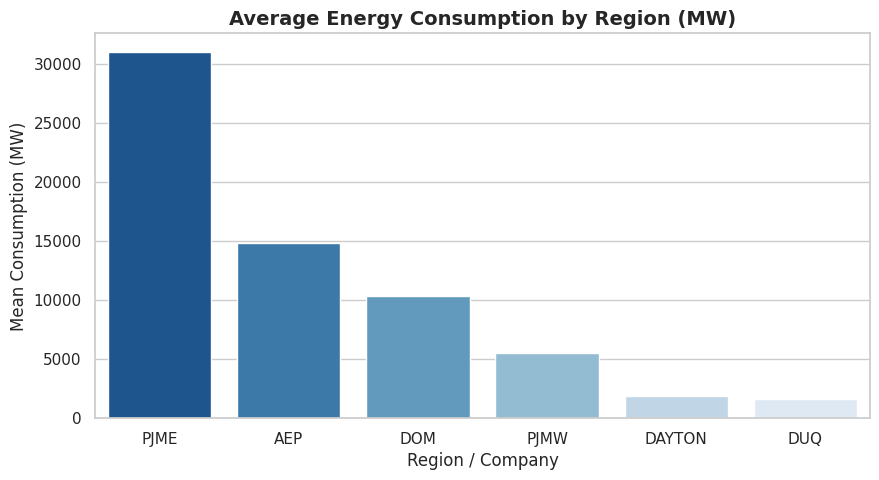

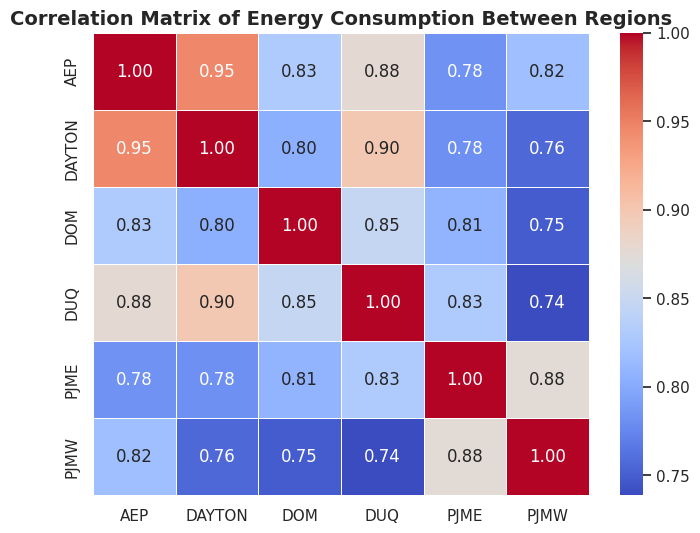

/tmp/ipykernel_21284/4060130312.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=data, x='Hour', y='PJME', label='PJME', marker='o', ci=None)
/tmp/ipykernel_21284/4060130312.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=data, x='Hour', y='AEP', label='AEP', marker='s', ci=None)


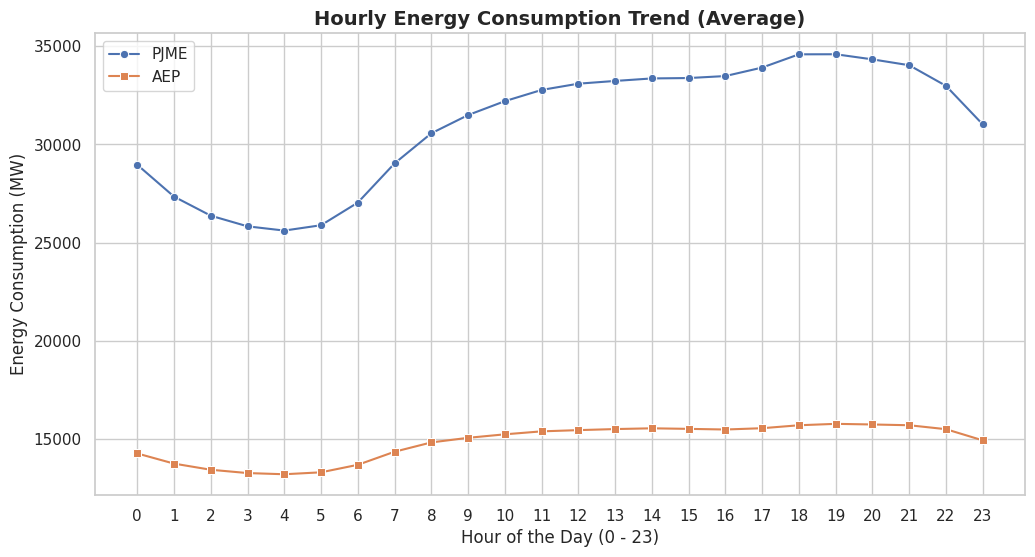

/tmp/ipykernel_21284/4060130312.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=data, x='Month', y='PJME', color='orange', marker='D', ci=None)


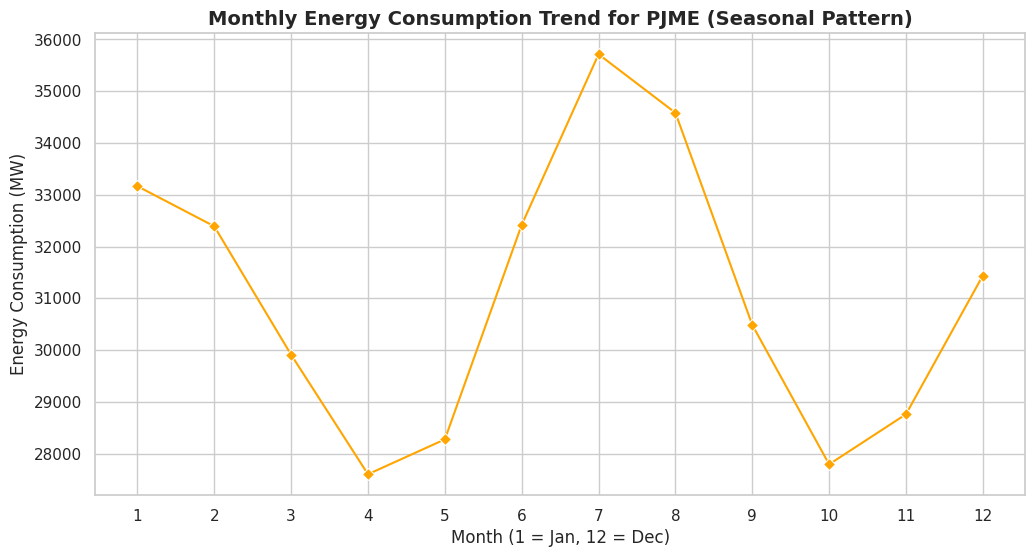

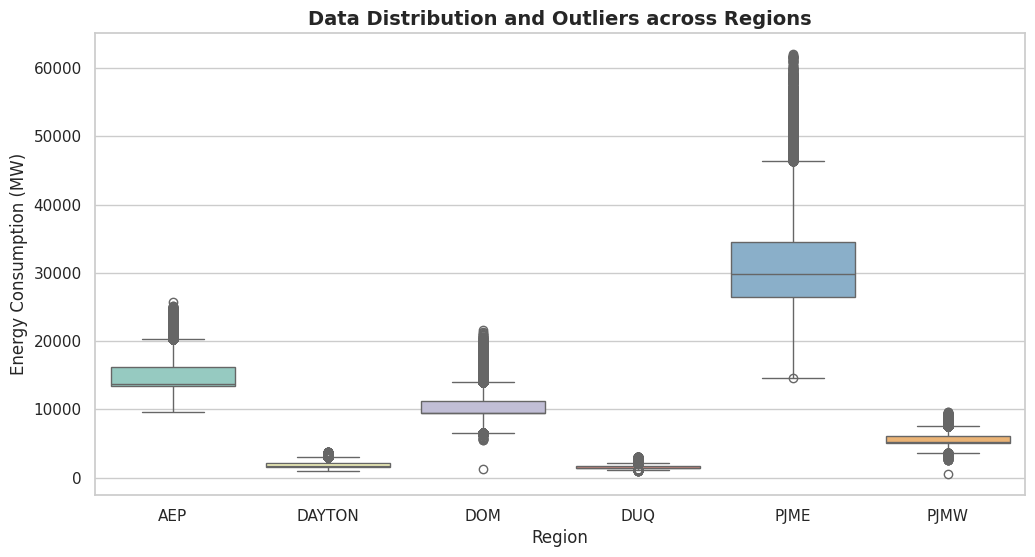

In [50]:
# Data Visualization

sns.set_theme(style="whitegrid")

# (Bar Plot)
plt.figure(figsize=(10, 5))
mean_consumption = data[regions].mean().sort_values(ascending=False)
sns.barplot(x=mean_consumption.index, y=mean_consumption.values, palette="Blues_r")
plt.title("Average Energy Consumption by Region (MW)", fontsize=14, fontweight='bold')
plt.xlabel("Region / Company", fontsize=12)
plt.ylabel("Mean Consumption (MW)", fontsize=12)
plt.show()

# (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(data[regions].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Energy Consumption Between Regions", fontsize=14, fontweight='bold')
plt.show()

# (Hourly Trend)
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Hour', y='PJME', label='PJME', marker='o', ci=None)
sns.lineplot(data=data, x='Hour', y='AEP', label='AEP', marker='s', ci=None)
plt.title("Hourly Energy Consumption Trend (Average)", fontsize=14, fontweight='bold')
plt.xlabel("Hour of the Day (0 - 23)", fontsize=12)
plt.ylabel("Energy Consumption (MW)", fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.show()

# (Monthly Trend / Seasonal)
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Month', y='PJME', color='orange', marker='D', ci=None)
plt.title("Monthly Energy Consumption Trend for PJME (Seasonal Pattern)", fontsize=14, fontweight='bold')
plt.xlabel("Month (1 = Jan, 12 = Dec)", fontsize=12)
plt.ylabel("Energy Consumption (MW)", fontsize=12)
plt.xticks(range(1, 13))
plt.show()

# (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[regions], palette="Set3")
plt.title("Data Distribution and Outliers across Regions", fontsize=14, fontweight='bold')
plt.ylabel("Energy Consumption (MW)", fontsize=12)
plt.xlabel("Region", fontsize=12)
plt.show()